In [1]:
import pandas as pd
import io
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

csv_data = """
age,tenure_months,avg_sessions_week,support_tickets,last30d_spend,discount_used,plan_premium,churn
19,1,10,0,5,1,0,0
22,2,9,0,8,1,0,0
24,3,7,1,12,0,0,0
27,4,6,1,15,0,0,0
31,6,5,2,18,0,0,0
35,8,4,2,22,0,0,0
41,10,3,3,25,0,0,1
29,2,2,3,9,1,0,1
33,3,2,4,11,0,0,1
45,12,2,4,20,0,0,1
26,1,1,2,6,1,0,1
38,7,3,1,30,0,1,0
42,9,4,1,35,0,1,0
30,5,5,0,28,0,1,0
28,4,6,0,24,0,1,0
23,2,8,0,10,1,0,0
37,11,2,5,18,0,0,1
34,6,3,3,16,0,0,1
40,13,4,2,40,0,1,0
21,1,6,2,7,1,0,0
32,8,5,0,26,0,1,0
36,9,2,3,21,0,0,1
25,3,7,0,14,0,0,0
39,14,3,4,23,0,0,1
27,5,6,1,19,0,0,0
44,15,2,4,27,0,0,1
29,7,4,0,32,0,1,0
31,9,5,1,34,0,1,0
46,16,1,5,22,0,0,1
20,2,9,0,9,1,0,0
"""
df = pd.read_csv(io.StringIO(csv_data))

In [2]:


categoric_columns = []
numeric_columns = []
col = df.columns.drop("churn")

for co in col:
    if df[co].dtype == "O":
        categoric_columns.append(co)
    else:
        numeric_columns.append(co)

print(categoric_columns)
print(numeric_columns)

[]
['age', 'tenure_months', 'avg_sessions_week', 'support_tickets', 'last30d_spend', 'discount_used', 'plan_premium']


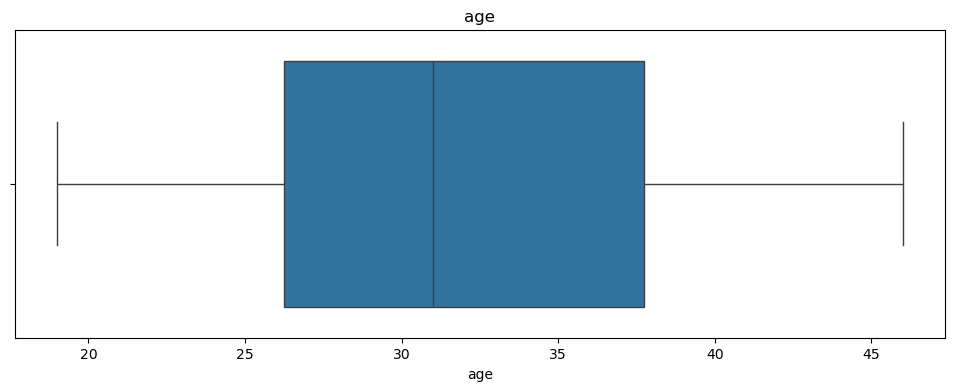

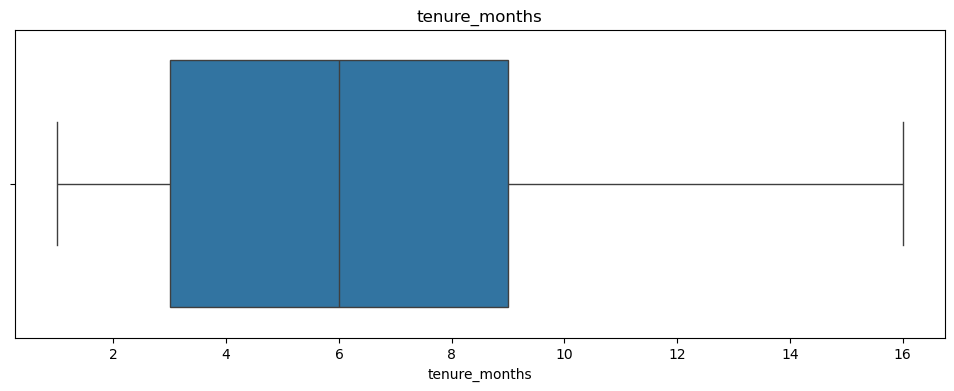

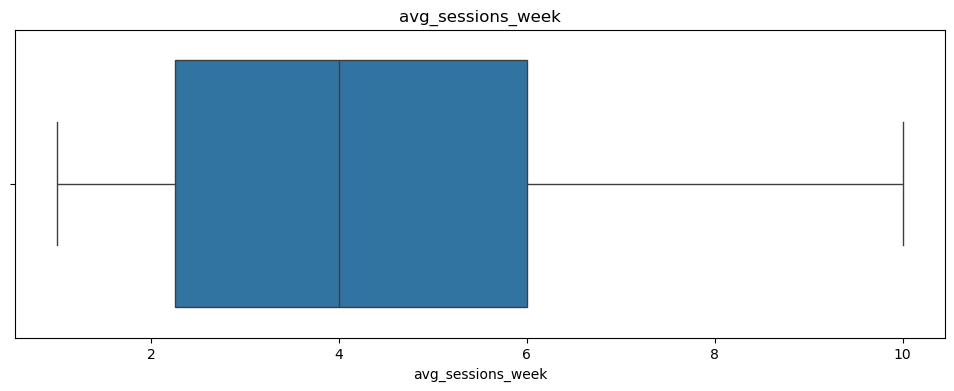

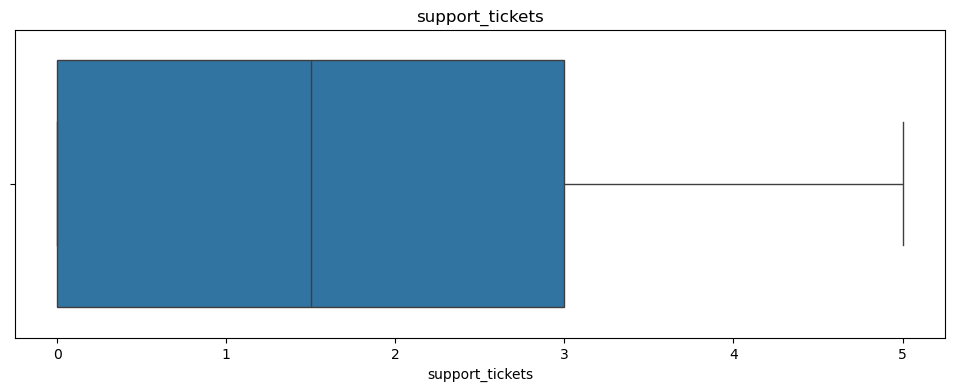

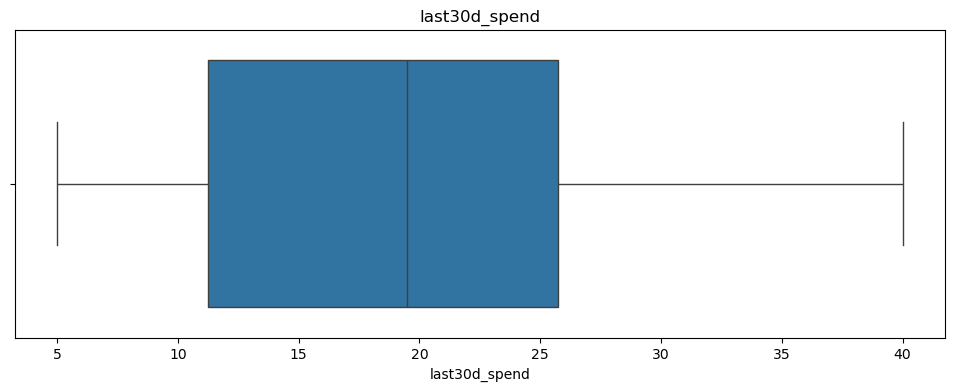

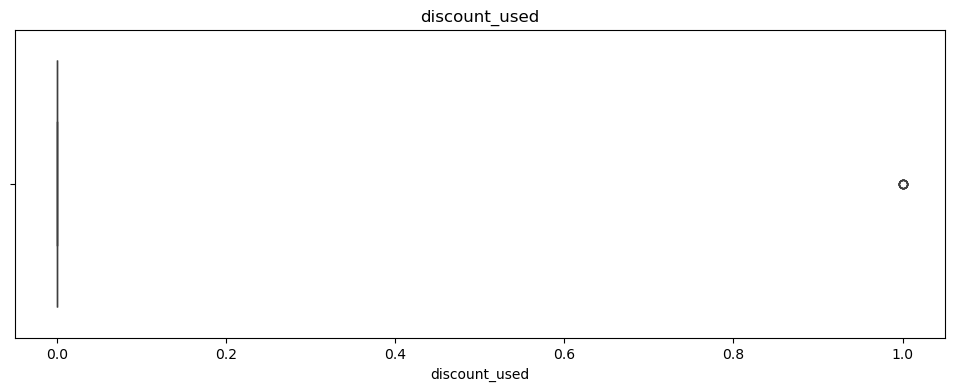

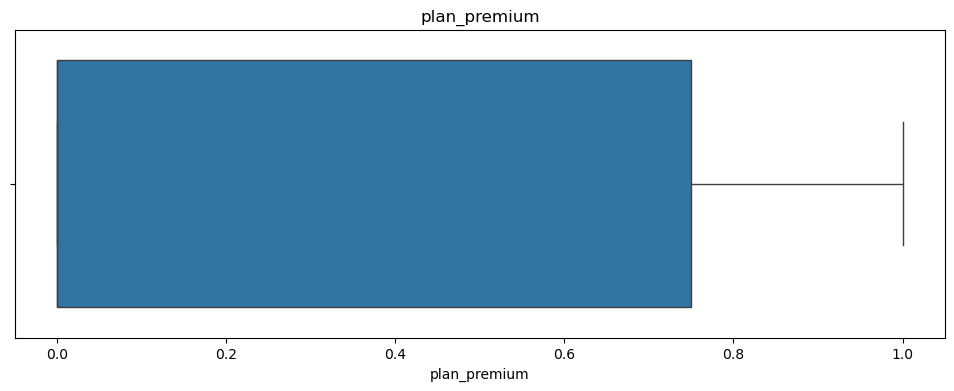

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt


columns = df.columns.drop("churn")


for col in columns:
    plt.figure(figsize=(12,4))
    sns.boxplot(x=df[col])   # veya y=df[col]
    plt.title(col)
    plt.show()



In [4]:
X = df.drop("churn",axis=1)
y = df["churn"]

X_train,X_test ,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=13)

countt=y_test.value_counts(normalize=True)
print(countt)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=192,          # ipucu: 1000 gibi bir şey
        class_weight="balanced",      # ipucu: dengesizse "balanced", değilse None
        random_state=42       # ipucu: 42
    ))
])

pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

churn
0    0.666667
1    0.333333
Name: proportion, dtype: float64


1.0

In [19]:
scaler = pipe.named_steps["scaler"]
scaler.mean_, scaler.scale_

y_pred= LogisticRegression().predict(X_train)
y_pred

NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

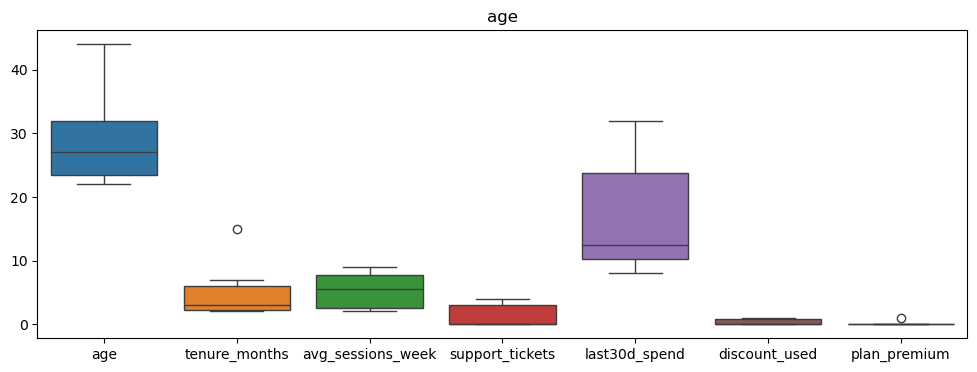

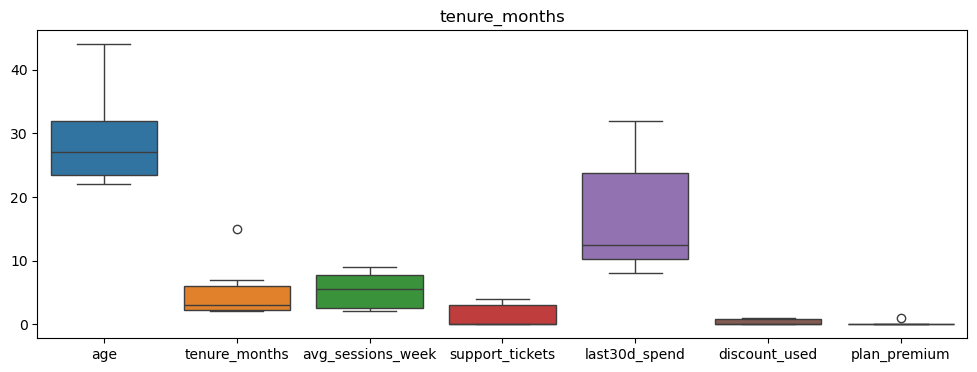

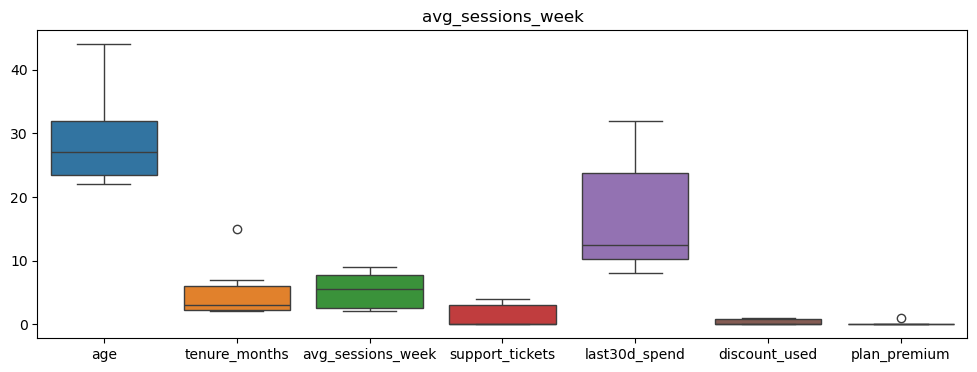

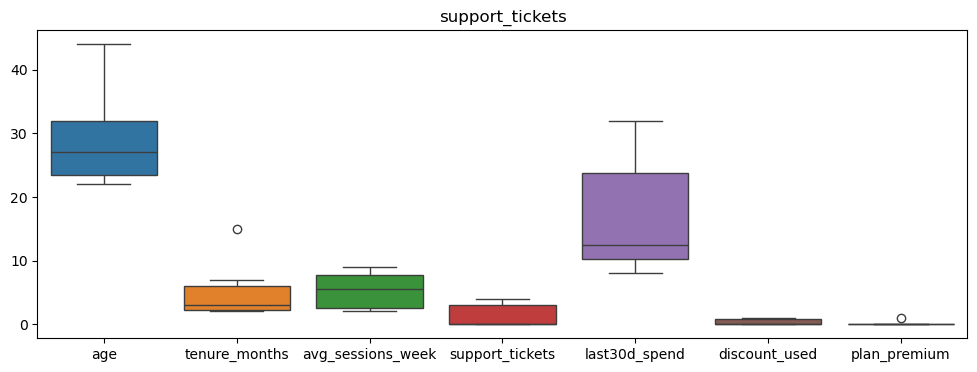

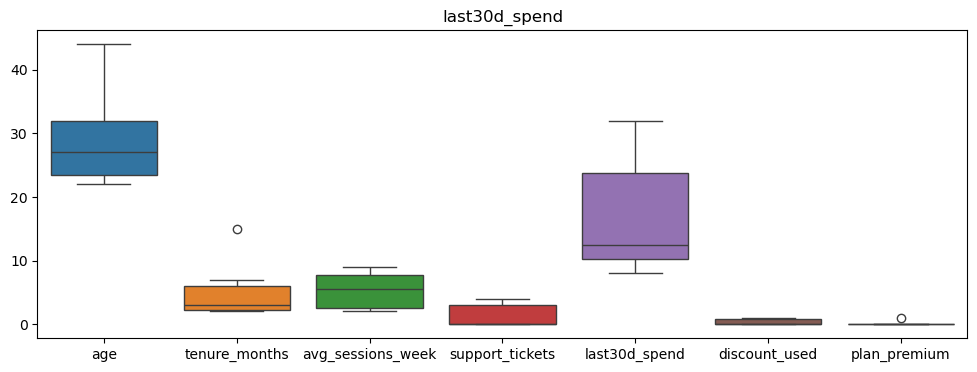

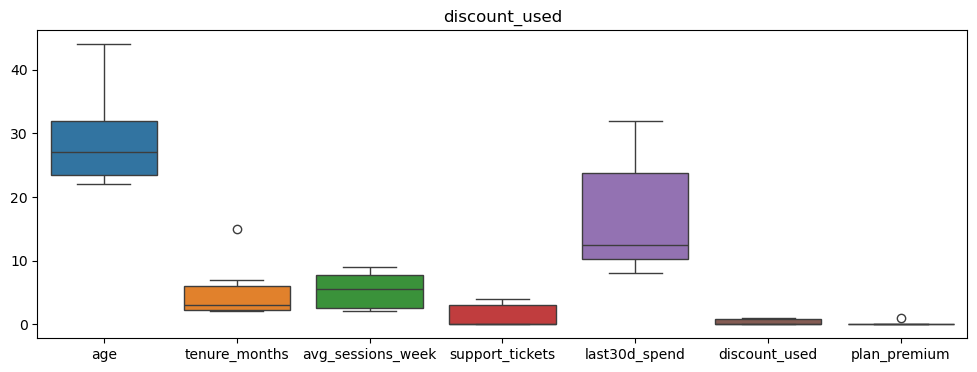

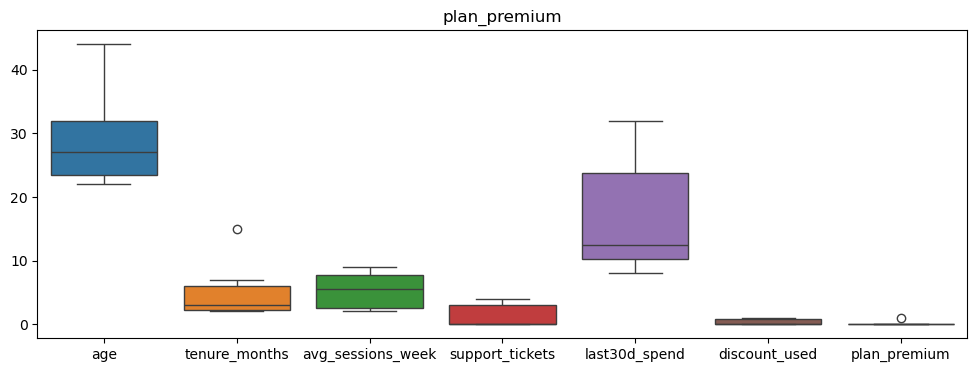

In [18]:
print(classification_report())

TypeError: missing a required argument: 'y_true'